In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH  = "nba_data/final/nba_ml_dataset.csv"
ESPN_PATH  = "nba_data/final/2025_espn_predicted_wins.csv"
OUTPUT_DIR = "models"

# ── Model config ───────────────────────────────────────────────────────────────
N_PLAYERS   = 8
RANDOM_SEED = 1

# ── Year-based split boundaries ────────────────────────────────────────────────
YEAR_COL    = "season"
TRAIN_YEARS = range(2010, 2024)   # 2010–2023  →  training
VAL_YEARS   = [2024]              # 2024       →  validation / early stopping
TEST_YEARS  = range(2003, 2010)   # 2003–2009  →  held-out old-era test
PRED_YEAR   = 2025                # roster year
STAT_YEAR   = 2024                # stat source year for 2025 prediction rows

# ── Column dropout mask (admin / non-predictive only) ─────────────────────────
DROP_PLAYER_COLS: list[str] = [
    "draft_year", "draft_round", "draft_number", "college", "country",
]

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
print("Loading data...")
df = pd.read_csv(DATA_PATH)
print(f"  {df.shape[0]} team-seasons, {df.shape[1]} columns")

if YEAR_COL not in df.columns:
    raise ValueError(f"Year column '{YEAR_COL}' not found. Available: {list(df.columns)}")

print(f"  Years in file : {sorted(df[YEAR_COL].unique())}")
print(f"  Teams in file : {sorted(df['team'].unique())}")
print(f"  Wins range    : {df['reg_season_wins'].min()} – {df['reg_season_wins'].max()}")

Loading data...
  657 team-seasons, 572 columns
  Years in file : [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Teams in file : ['ATL', 'BKN', 'BOS', 'CHA', 'CHI', 'CLE', 'DAL', 'DEN', 'DET', 'GS', 'HOU', 'IND', 'LAC', 'LAL', 'MEM', 'MIA', 'MIL', 'MIN', 'NJ', 'NO', 'NY', 'OKC', 'ORL', 'PHI', 'PHX', 'POR', 'SA', 'SAC', 'TOR', 'UTAH', 'WSH']
  Wins range    : 7.0 – 73.0


In [4]:
print(f"Building {PRED_YEAR} prediction rows using {STAT_YEAR} player stats...")

player_slots  = [f"p{i}" for i in range(1, N_PLAYERS + 1)]

def slot_stat_cols(slot: str) -> list[str]:
    return [c for c in df.columns
            if c.startswith(f"{slot}_") and not c.endswith("_name")]

# Detect every slot present in the CSV
all_csv_slots = sorted({
    c.split("_")[0]
    for c in df.columns
    if c.startswith("p") and "_" in c and c.split("_")[0][1:].isdigit()
}, key=lambda s: int(s[1:]))

# Build player stat + team lookups from STAT_YEAR
# Always overwrite on each occurrence → last row = destination team for traded players
stat_year_rows: pd.DataFrame = df[df[YEAR_COL] == STAT_YEAR].copy()
player_stat_lookup: dict[str, dict[str, float]] = {}
player_team_lookup: dict[str, list[str]]        = {}

for slot in all_csv_slots:
    name_col  = f"{slot}_name"
    stat_cols = slot_stat_cols(slot)
    if name_col not in stat_year_rows.columns or not stat_cols:
        continue
    sub = stat_year_rows[["team", name_col] + stat_cols].dropna(subset=[name_col])
    for _, row in sub.iterrows():
        pname = row[name_col]
        if pd.isna(pname):
            continue
        player_stat_lookup[pname] = {
            col.replace(f"{slot}_", ""): row[col] for col in stat_cols
        }
        player_team_lookup.setdefault(pname, [])
        team_val = str(row.get("team", ""))
        if team_val and team_val not in player_team_lookup[pname]:
            player_team_lookup[pname].append(team_val)

print(f"  Players found in {STAT_YEAR} data: {len(player_stat_lookup)}")

pred_rows_raw = df[df[YEAR_COL] == PRED_YEAR].copy()
if len(pred_rows_raw) == 0:
    raise ValueError(f"No rows found for season {PRED_YEAR}. Check CSV contains 2025 roster rows.")

print(f"  {len(pred_rows_raw)} teams found in {PRED_YEAR} roster data")

pred_rows       = pred_rows_raw.copy()
swapped_count   = 0
missing_players = []

for slot in player_slots:
    name_col  = f"{slot}_name"
    stat_cols = slot_stat_cols(slot)
    if name_col not in pred_rows.columns:
        continue
    for idx, row in pred_rows.iterrows():
        pname = row.get(name_col)
        if pd.isna(pname):
            continue
        if pname in player_stat_lookup:
            stats = player_stat_lookup[pname]
            for col in stat_cols:
                suffix = col.replace(f"{slot}_", "")
                if suffix in stats:
                    pred_rows.at[idx, col] = stats[suffix]
            swapped_count += 1
        else:
            missing_players.append((row.get("team", "?"), slot, pname))

print(f"  Stat swaps performed : {swapped_count}")

traded = {n: teams for n, teams in player_team_lookup.items() if len(teams) > 1}
if traded:
    print(f"  Traded players in {STAT_YEAR} (using LAST/destination team stats): {len(traded)}")
    for name, teams in list(traded.items())[:10]:
        print(f"    {name}: {' -> '.join(teams)}")
    if len(traded) > 10:
        print(f"    ... and {len(traded) - 10} more")

if missing_players:
    print(f"  Players with no {STAT_YEAR} stats (rookie/overseas, zero-filled): {len(missing_players)}")
    for team, slot, name in missing_players[:10]:
        print(f"    {team} {slot}: {name}")
    if len(missing_players) > 10:
        print(f"    ... and {len(missing_players) - 10} more")

Building 2025 prediction rows using 2024 player stats...
  Players found in 2024 data: 226
  30 teams found in 2025 roster data
  Stat swaps performed : 168
  Traded players in 2024 (using LAST/destination team stats): 1
    Dennis Schröder: TOR -> BKN
  Players with no 2024 stats (rookie/overseas, zero-filled): 72
    BKN p1: Jalen Wilson
    DEN p1: Christian Braun
    NO p1: Yves Missi
    WSH p1: Bub Carrington
    ATL p2: Dyson Daniels
    BKN p2: Keon Johnson
    DEN p2: Christian Braun
    UTAH p2: Isaiah Collier
    CHA p3: LaMelo Ball
    DAL p3: Naji Marshall
    ... and 62 more


In [5]:
stat_cols_check = [
    c for c in df.columns
    if any(c.startswith(f"p{i}_") for i in range(1, N_PLAYERS + 1))
    and not c.endswith("_name")
]

# Drop empty rows from historical data only
df_hist    = df[df[YEAR_COL] != PRED_YEAR].copy()
empty_mask = df_hist[stat_cols_check].isnull().all(axis=1)
n_empty    = empty_mask.sum()

if n_empty > 0:
    print(f"⚠  {n_empty} historical rows with no player stats excluded:")
    empty_summary = (
        df_hist[empty_mask].groupby(YEAR_COL)["team"]
        .apply(list).reset_index()
    )
    for _, row in empty_summary.iterrows():
        teams   = row["team"]
        preview = ", ".join(teams[:5]) + ("..." if len(teams) > 5 else "")
        print(f"   Year {int(row[YEAR_COL])}: {len(teams)} teams ({preview})")
else:
    print("  No empty historical rows found ✓")

df_clean = pd.concat([df_hist[~empty_mask], pred_rows], ignore_index=True)
print(f"  Usable rows (incl. 2025 pred rows): {len(df_clean)}")

# ── Apply splits ───────────────────────────────────────────────────────────────
train_mask = df_clean[YEAR_COL].isin(TRAIN_YEARS)
val_mask   = df_clean[YEAR_COL].isin(VAL_YEARS)
test_mask  = df_clean[YEAR_COL].isin(TEST_YEARS)
pred_mask  = df_clean[YEAR_COL] == PRED_YEAR

print("\n── Year-based splits ─────────────────────────────────────")
for label, mask, yr in [
    ("Train",    train_mask, f"{min(TRAIN_YEARS)}–{max(TRAIN_YEARS)}"),
    ("Validate", val_mask,   str(VAL_YEARS[0])),
    ("Test",     test_mask,  f"{min(TEST_YEARS)}–{max(TEST_YEARS)}"),
    ("Predict",  pred_mask,  str(PRED_YEAR)),
]:
    count  = mask.sum()
    status = f"{count:>3} rows ✓" if count > 0 else "⚠  NO ROWS — check YEAR_COL name/values"
    print(f"  {label:<9}: years {yr}  →  {status}")

unassigned = df_clean[~(train_mask | val_mask | test_mask | pred_mask)][YEAR_COL].unique()
if len(unassigned):
    print(f"\n  ℹ  Years not assigned to any split (ignored): {sorted(unassigned)}")

  No empty historical rows found ✓
  Usable rows (incl. 2025 pred rows): 657

── Year-based splits ─────────────────────────────────────
  Train    : years 2010–2023  →  390 rows ✓
  Validate : years 2024  →   30 rows ✓
  Test     : years 2003–2009  →  207 rows ✓
  Predict  : years 2025  →   30 rows ✓


In [6]:
NAME_COLS = [c for c in df.columns if c.endswith("_name")]
META_COLS = [
    YEAR_COL, "split", "team", "reg_season_wins", "reg_losses",
    "team_avg_bpm", "team_avg_per", "team_max_usg",
    "team_players_qualified", "team_total_vorp",
    "team_total_ws", "team_usg_gini",
]
EXCLUDE = set(META_COLS + NAME_COLS)

ALL_PLAYER_SLOTS = set(
    c for c in df_clean.columns
    if any(c.startswith(f"p{i}_") for i in range(1, 11))
)
ALLOWED_SLOTS = set(
    c for c in ALL_PLAYER_SLOTS
    if any(c.startswith(f"p{i}_") for i in range(1, N_PLAYERS + 1))
)

DROPPED_BY_MASK = set()
for suffix in DROP_PLAYER_COLS:
    for i in range(1, N_PLAYERS + 1):
        DROPPED_BY_MASK.add(f"p{i}_{suffix}")
print(f"  Dropping {len(DROPPED_BY_MASK)} columns via dropout mask.")

FEAT_COLS = [
    c for c in df_clean.columns
    if c not in EXCLUDE
    and c not in DROPPED_BY_MASK
    and df_clean[c].dtype in ["float64", "int64"]
    and (c not in ALL_PLAYER_SLOTS or c in ALLOWED_SLOTS)
]
print(f"  Feature columns: {len(FEAT_COLS)}  (using {N_PLAYERS} player slots)")

  Dropping 40 columns via dropout mask.
  Feature columns: 400  (using 8 player slots)


In [7]:
X_train = df_clean.loc[train_mask, FEAT_COLS].fillna(0)
y_train = df_clean.loc[train_mask, "reg_season_wins"]

X_val   = df_clean.loc[val_mask,   FEAT_COLS].fillna(0)
y_val   = df_clean.loc[val_mask,   "reg_season_wins"]

X_test  = df_clean.loc[test_mask,  FEAT_COLS].fillna(0)
y_test  = df_clean.loc[test_mask,  "reg_season_wins"]

X_pred  = df_clean.loc[pred_mask,  FEAT_COLS].fillna(0)

print(f"  Train  : {len(X_train):>3} rows  ({min(TRAIN_YEARS)}–{max(TRAIN_YEARS)})")
print(f"  Val    : {len(X_val):>3} rows  ({VAL_YEARS[0]})")
print(f"  Test   : {len(X_test):>3} rows  ({min(TEST_YEARS)}–{max(TEST_YEARS)})")
print(f"  Predict: {len(X_pred):>3} rows  ({PRED_YEAR}, no ground truth)")

  Train  : 390 rows  (2010–2023)
  Val    :  30 rows  (2024)
  Test   : 207 rows  (2003–2009)
  Predict:  30 rows  (2025, no ground truth)


In [8]:
print("Training XGBoost...")

model = XGBRegressor(
    random_state=RANDOM_SEED,
    min_child_weight=15,
    max_depth=2,
    reg_lambda=8,
    reg_alpha=2,
    subsample=0.7,
    colsample_bytree=0.4,
    learning_rate=0.005,
    n_estimators=10000,
    early_stopping_rounds=300,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

print(f"\n  Best iteration: {model.best_iteration}")

Training XGBoost...
[0]	validation_0-rmse:12.18285	validation_1-rmse:13.23452
[100]	validation_0-rmse:9.56402	validation_1-rmse:10.42056
[200]	validation_0-rmse:7.91575	validation_1-rmse:8.65126
[300]	validation_0-rmse:6.83740	validation_1-rmse:7.52566
[400]	validation_0-rmse:6.04798	validation_1-rmse:6.73819
[500]	validation_0-rmse:5.45019	validation_1-rmse:6.13739
[600]	validation_0-rmse:4.98586	validation_1-rmse:5.73470
[700]	validation_0-rmse:4.60888	validation_1-rmse:5.37976
[800]	validation_0-rmse:4.31092	validation_1-rmse:5.09935
[900]	validation_0-rmse:4.06780	validation_1-rmse:4.91254
[1000]	validation_0-rmse:3.86135	validation_1-rmse:4.74662
[1100]	validation_0-rmse:3.69312	validation_1-rmse:4.62317
[1200]	validation_0-rmse:3.53646	validation_1-rmse:4.51213
[1300]	validation_0-rmse:3.40359	validation_1-rmse:4.42982
[1400]	validation_0-rmse:3.28163	validation_1-rmse:4.36113
[1500]	validation_0-rmse:3.17198	validation_1-rmse:4.30113
[1600]	validation_0-rmse:3.07206	validation_1

In [9]:
def report(label, X, y, df_rows, plot=False):
    """Print MAE/R² and optionally produce an actual-vs-predicted scatter."""
    preds = model.predict(X)
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)
    print(f"\n  ── {label} ──────────────────────────────────────")
    print(f"     MAE : {mae:.2f} wins")
    print(f"     R²  : {r2:.3f}")

    results = df_rows[[YEAR_COL, "team", "reg_season_wins"]].copy()
    results["predicted"] = np.round(preds, 1)
    results["error"]     = np.round(preds - y.values, 1)

    if not plot:
        return results

    plot_data = sorted(
        zip(results["team"], results[YEAR_COL],
            results["reg_season_wins"], results["predicted"]),
        key=lambda x: x[3]
    )
    teams     = [f"{d[0]}·{d[1]}" for d in plot_data]
    actual    = np.array([d[2] for d in plot_data])
    predicted = np.array([d[3] for d in plot_data])
    x         = np.arange(len(teams))

    BG, PANEL, GRID = "#0d1117", "#161b22", "#21262d"
    ACT, PRED, TEXT = "#3fb950", "#f85149", "#e6edf3"
    SUB             = "#8b949e"

    fig, ax = plt.subplots(figsize=(max(20, len(teams) * 0.45), 9))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(PANEL)

    for i in range(len(teams)):
        ax.plot([x[i], x[i]], [predicted[i], actual[i]],
                color="white", alpha=0.35, linewidth=1.4,
                linestyle=(0, (3, 3)), zorder=2)

    ax.scatter(x, predicted, color=PRED, s=90, zorder=4,
               edgecolors="white", linewidths=0.6)
    ax.scatter(x, actual,    color=ACT,  s=90, zorder=4,
               edgecolors="white", linewidths=0.6)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, linestyle="--")
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=SUB, length=0)
    ax.set_xticks(x)
    ax.set_xticklabels(teams, rotation=45, ha="right",
                       fontsize=7, color=TEXT, fontfamily="monospace")
    ax.set_ylabel("Wins", color=TEXT, fontsize=12, labelpad=10)
    ax.yaxis.set_tick_params(labelcolor=SUB, labelsize=10)
    ax.set_xlim(-0.7, len(teams) - 0.3)
    ax.set_ylim(0, max(actual.max(), predicted.max()) + 8)

    fig.text(0.5, 0.97, f"NBA {label.strip()} — Actual vs Expected Wins",
             ha="center", va="top", fontsize=18, fontweight="bold", color=TEXT)
    fig.text(0.5, 0.925,
             f"Sorted by expected wins  ·  MAE: {mae:.2f}  ·  R²: {r2:.3f}",
             ha="center", va="top", fontsize=10, color=SUB)

    pred_h = mlines.Line2D([], [], color=PRED, marker='o', markersize=8,
                           linestyle='None', markeredgecolor='white',
                           markeredgewidth=0.6, label='Expected Wins')
    act_h  = mlines.Line2D([], [], color=ACT,  marker='o', markersize=8,
                           linestyle='None', markeredgecolor='white',
                           markeredgewidth=0.6, label='Actual Wins')
    ax.legend(handles=[pred_h, act_h], loc="upper left", framealpha=0.2,
              facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    safe = label.strip().replace(" ", "_").replace("/", "-")
    plt.savefig(f"report_{safe}.png", dpi=160, bbox_inches="tight", facecolor=BG)
    plt.show()
    return results

══ Evaluation ══════════════════════════════════════════

  ── Train (2010–2023) ──────────────────────────────────────
     MAE : 0.56 wins
     R²  : 0.996

  ── Val (2024) ──────────────────────────────────────
     MAE : 2.82 wins
     R²  : 0.918


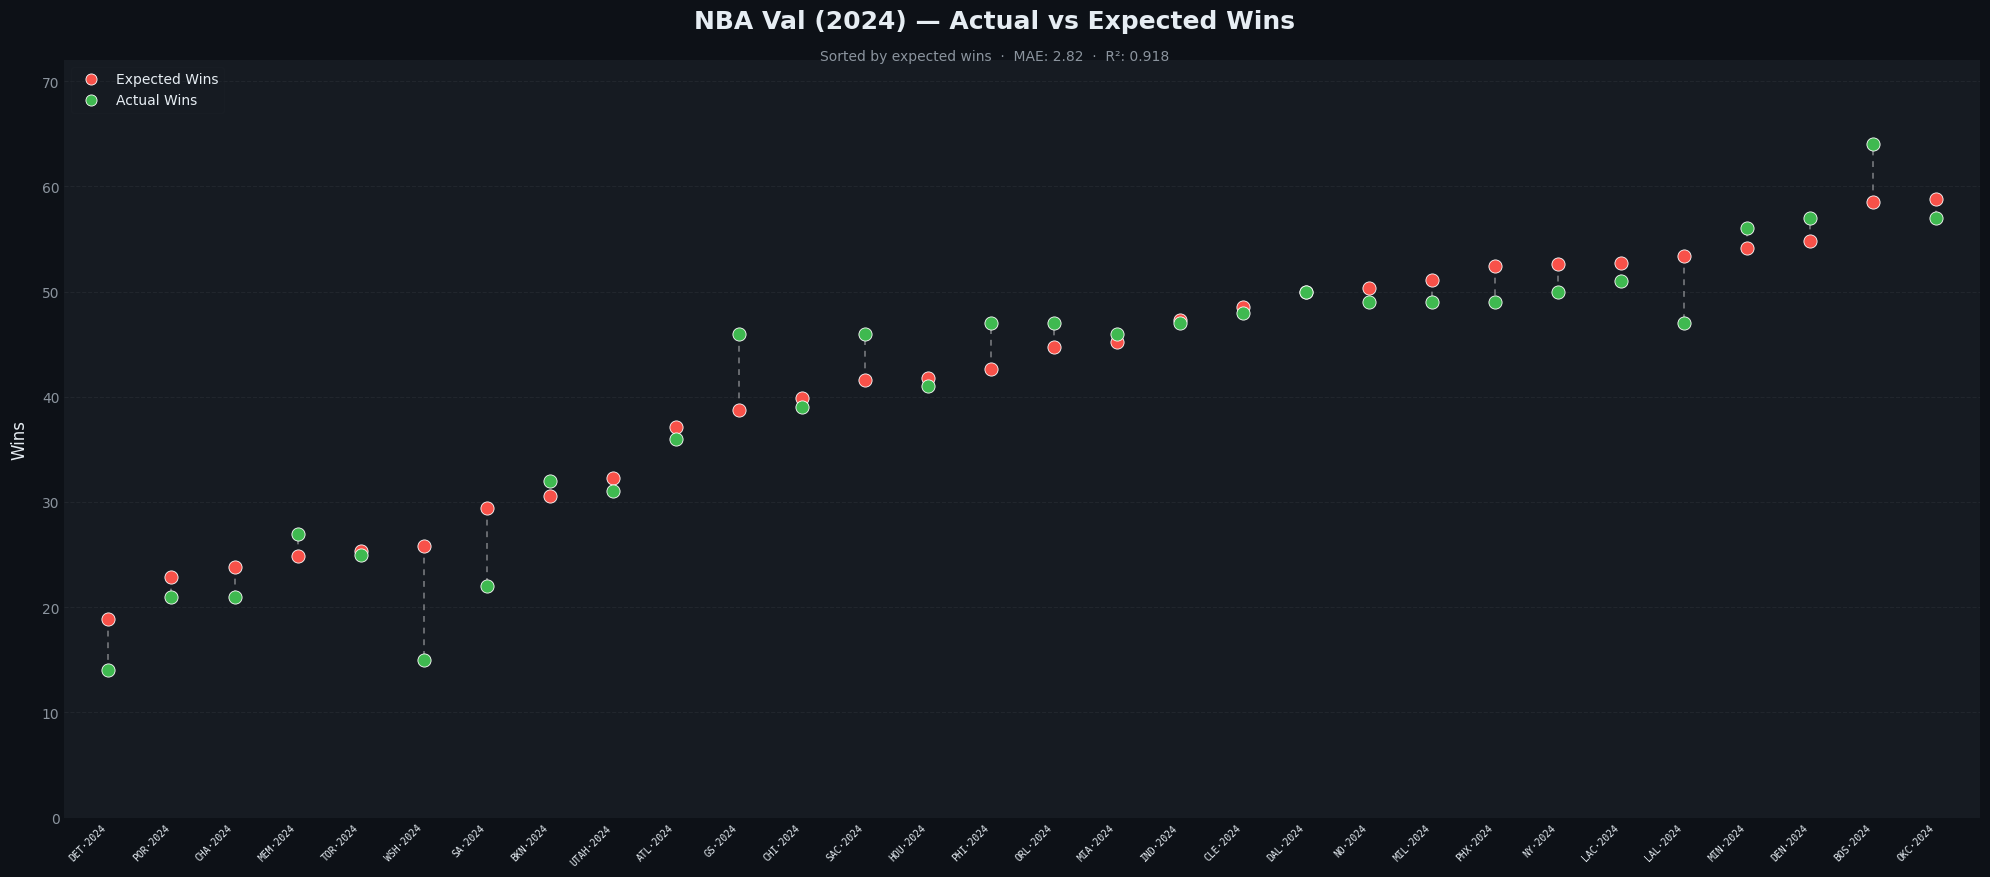

,season,team,reg_season_wins,predicted,error
597,2024,ATL,36.0,37.099998,1.1
598,2024,BOS,64.0,58.500000,-5.5
599,2024,BKN,32.0,30.600000,-1.4
600,2024,CHA,21.0,23.799999,2.8
601,2024,CHI,39.0,39.900002,0.9
602,2024,CLE,48.0,48.500000,0.5
603,2024,DAL,50.0,50.000000,0.0
604,2024,DEN,57.0,54.799999,-2.2
605,2024,DET,14.0,18.900000,4.9
606,2024,GS,46.0,38.700001,-7.3


In [10]:
print("══ Evaluation ══════════════════════════════════════════")
report("Train (2010–2023)", X_train, y_train, df_clean[train_mask])
report("Val (2024)",        X_val,   y_val,   df_clean[val_mask], plot=True)

⚠  Running old-era test evaluation — do this only once!

  ── Test (2003–2009) ──────────────────────────────────────
     MAE : 3.86 wins
     R²  : 0.839


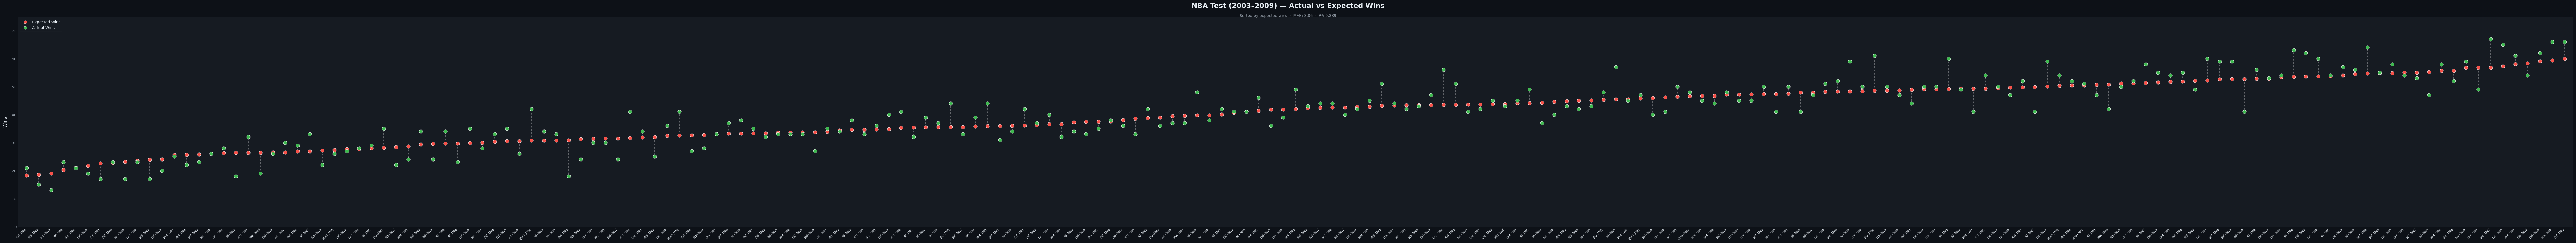

In [ ]:
print("Running old-era test evaluation")
test_results = report("Test (2003–2009)", X_test, y_test,
                      df_clean[test_mask], plot=True)

══ Per-Season MAE (old-era test) ════════════════════════

  Season      MAE      R²  Teams
  ────────────────────────────────
  2003       3.82   0.837     28
  2004       3.91   0.740     29
  2005       4.26   0.814     30
  2006       3.79   0.822     30
  2007       3.94   0.796     30
  2008       3.73   0.892     30
  2009       3.54   0.904     30

  Overall old-era MAE (mean of season MAEs): 3.86 wins


C:\Users\lucas\AppData\Local\Temp\ipykernel_14452\2875739395.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: r2_score(g["reg_season_wins"], g["predicted"]))


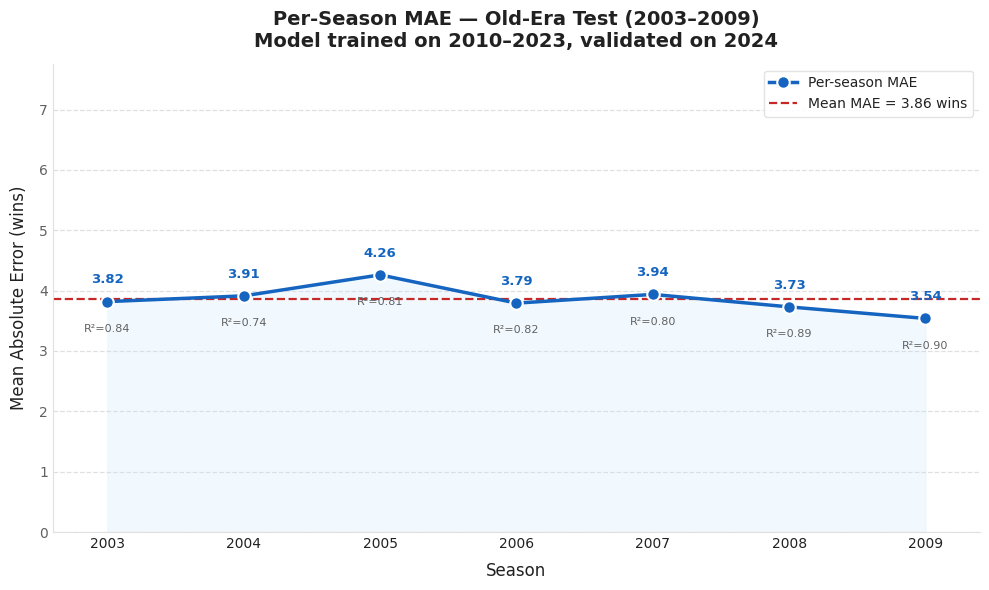

  Saved: report_old_era_mae_by_season.png


In [12]:
print("══ Per-Season MAE (old-era test) ════════════════════════")

test_preds = model.predict(X_test)
test_rows  = df_clean[test_mask].copy().reset_index(drop=True)
test_rows["predicted"] = test_preds
test_rows["abs_error"] = np.abs(test_rows["predicted"] - test_rows["reg_season_wins"])

season_mae = (
    test_rows.groupby(YEAR_COL)["abs_error"]
    .mean().reset_index()
    .rename(columns={"abs_error": "mae"})
    .sort_values(YEAR_COL)
)

season_r2 = (
    test_rows.groupby(YEAR_COL)
    .apply(lambda g: r2_score(g["reg_season_wins"], g["predicted"]))
    .reset_index().rename(columns={0: "r2"})
    .sort_values(YEAR_COL)
)

season_stats = season_mae.merge(season_r2, on=YEAR_COL)
print(f"\n  {'Season':<8} {'MAE':>6} {'R²':>7} {'Teams':>6}")
print("  " + "─" * 32)
for _, row in season_stats.iterrows():
    n_teams = (test_rows[YEAR_COL] == row[YEAR_COL]).sum()
    print(f"  {int(row[YEAR_COL]):<8} {row['mae']:>6.2f} {row['r2']:>7.3f} {n_teams:>6}")

overall_mae = season_mae["mae"].mean()
print(f"\n  Overall old-era MAE (mean of season MAEs): {overall_mae:.2f} wins")

# ── Line chart ─────────────────────────────────────────────────────────────────
seasons  = season_stats[YEAR_COL].astype(int).tolist()
mae_vals = season_stats["mae"].tolist()
r2_vals  = season_stats["r2"].tolist()

LINE_C = "#1565C0"
FILL_C = "#BBDEFB"
AVG_C  = "#C62828"
GRID_C = "#E0E0E0"
TEXT_C = "#212121"
SUB_C  = "#616161"

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.fill_between(seasons, mae_vals, alpha=0.18, color=FILL_C, zorder=1)
ax.plot(seasons, mae_vals, color=LINE_C, linewidth=2.5, marker="o",
        markersize=9, markerfacecolor=LINE_C, markeredgecolor="white",
        markeredgewidth=1.5, zorder=3, label="Per-season MAE")

for sx, my, ry in zip(seasons, mae_vals, r2_vals):
    ax.annotate(f"{my:.2f}", xy=(sx, my), xytext=(0, 11),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold", color=LINE_C)
    ax.annotate(f"R²={ry:.2f}", xy=(sx, my), xytext=(0, -16),
                textcoords="offset points", ha="center", va="top",
                fontsize=8, color=SUB_C)

ax.axhline(overall_mae, color=AVG_C, linewidth=1.6, linestyle="--", zorder=2,
           label=f"Mean MAE = {overall_mae:.2f} wins")

ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID_C, linewidth=0.9, linestyle="--")
ax.xaxis.grid(False)
for side, spine in ax.spines.items():
    spine.set_visible(side in ("bottom", "left"))
    if side in ("bottom", "left"):
        spine.set_color(GRID_C)

ax.tick_params(axis="both", length=0, labelcolor=TEXT_C)
ax.set_xticks(seasons)
ax.set_xticklabels([str(s) for s in seasons], fontsize=10, color=TEXT_C)
ax.set_yticks(np.arange(0, max(mae_vals) + 3, 1))
ax.yaxis.set_tick_params(labelsize=10, labelcolor=SUB_C)
ax.set_ylim(0, max(mae_vals) + 3.5)
ax.set_xlim(min(seasons) - 0.4, max(seasons) + 0.4)
ax.set_xlabel("Season", fontsize=12, color=TEXT_C, labelpad=8)
ax.set_ylabel("Mean Absolute Error (wins)", fontsize=12, color=TEXT_C, labelpad=8)
ax.set_title("Per-Season MAE — Old-Era Test (2003–2009)\n"
             "Model trained on 2010–2023, validated on 2024",
             fontsize=14, fontweight="bold", color=TEXT_C, pad=12)
ax.legend(loc="upper right", frameon=True, framealpha=0.9,
          facecolor="white", edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=10)

plt.tight_layout()
plt.savefig("report_old_era_mae_by_season.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("  Saved: report_old_era_mae_by_season.png")

In [13]:
print(f"══ 2024-25 Predictions (roster={PRED_YEAR}, stats={STAT_YEAR}) ══════════")

pred_wins = model.predict(X_pred)

pred_df = df_clean.loc[pred_mask, ["team", "reg_season_wins"]].copy().reset_index(drop=True)
pred_df.rename(columns={"reg_season_wins": "actual_wins"}, inplace=True)
pred_df["model_pred_wins"]   = np.round(pred_wins, 1)
pred_df["model_pred_losses"] = np.round(82 - pred_wins, 1)

# ── Load ESPN predictions ──────────────────────────────────────────────────────
espn_df = pd.read_csv(ESPN_PATH)
espn_df.columns = espn_df.columns.str.strip()

compare = pred_df.merge(
    espn_df[["team", "espn_pred_wins", "espn_pred_losses"]],
    on="team", how="left"
)

compare["model_err"] = np.round(compare["model_pred_wins"] - compare["actual_wins"], 1)
compare["espn_err"]  = np.round(compare["espn_pred_wins"]  - compare["actual_wins"], 1)

has_actual = compare["actual_wins"].notna()
if has_actual.sum() > 0:
    model_mae = np.abs(compare.loc[has_actual, "model_err"]).mean()
    espn_mae  = np.abs(compare.loc[has_actual & compare["espn_pred_wins"].notna(), "espn_err"]).mean()
    print(f"\n  Model MAE vs actual : {model_mae:.2f} wins")
    print(f"  ESPN  MAE vs actual : {espn_mae:.2f} wins")

compare = compare.sort_values("actual_wins", ascending=False).reset_index(drop=True)

print(f"\n{'Team':<6} {'Actual':>7} {'Model':>7} {'ESPN':>7} {'Mod Err':>8} {'ESPN Err':>9}")
print("─" * 48)
for _, row in compare.iterrows():
    actual = f"{row['actual_wins']:.0f}"    if pd.notna(row['actual_wins'])    else "N/A"
    model  = f"{row['model_pred_wins']:.1f}"
    espn   = f"{row['espn_pred_wins']:.1f}" if pd.notna(row['espn_pred_wins']) else "N/A"
    merr   = f"{row['model_err']:+.1f}"     if pd.notna(row['model_err'])      else "N/A"
    eerr   = f"{row['espn_err']:+.1f}"      if pd.notna(row['espn_err'])       else "N/A"
    print(f"  {row['team']:<6} {actual:>7} {model:>7} {espn:>7} {merr:>8} {eerr:>9}")

══ 2024-25 Predictions (roster=2025, stats=2024) ══════════

  Model MAE vs actual : 6.63 wins
  ESPN  MAE vs actual : 8.48 wins

Team    Actual   Model    ESPN  Mod Err  ESPN Err
────────────────────────────────────────────────
  OKC         68    62.5    51.2     -5.5     -16.8
  CLE         64    48.1    47.5    -15.9     -16.5
  BOS         61    53.2    56.0     -7.8      -5.0
  HOU         52    36.5    42.1    -15.5      -9.9
  NY          51    39.5    40.6    -11.5     -10.4
  LAC         50    51.6    42.4     +1.6      -7.6
  LAL         50    41.1    42.7     -8.9      -7.3
  IND         50    48.1    41.1     -1.9      -8.9
  DEN         50    51.2    46.3     +1.2      -3.7
  MIN         49    47.2    46.5     -1.8      -2.5
  MEM         48    33.3    44.4    -14.7      -3.6
  GS          48    45.0    41.8     -3.0      -6.2
  MIL         48    57.2    46.0     +9.2      -2.0
  DET         44    37.7    29.3     -6.3     -14.7
  ORL         41    41.9    38.7     +0.9  

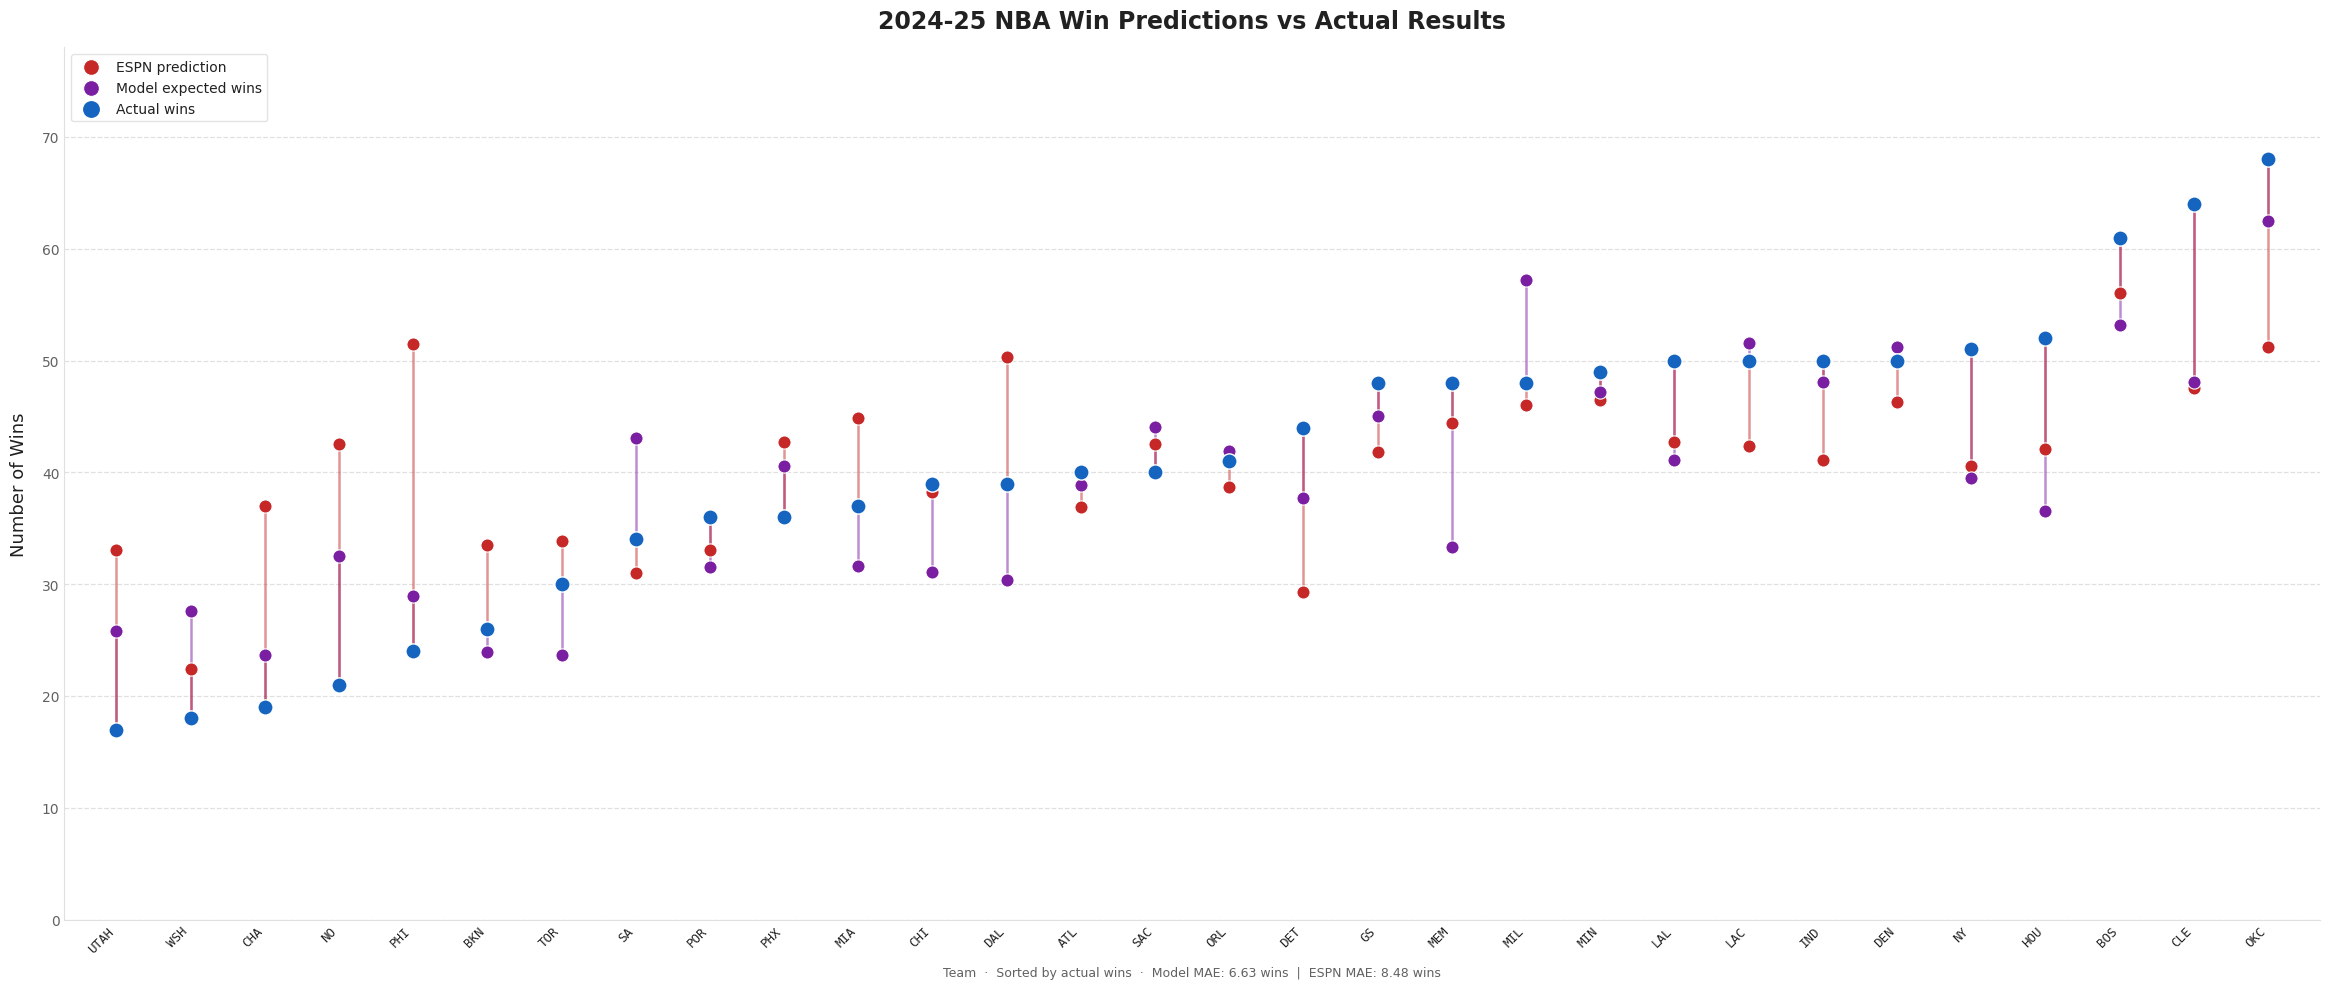

  Saved: 2025_predictions_vs_espn.csv
  Saved: report_2025_three_way.png


In [14]:
# ── Three-way scatter plot: Actual vs Model vs ESPN ────────────────────────────
plot_df  = compare.dropna(subset=["actual_wins"]).copy()
plot_df  = plot_df.sort_values("actual_wins").reset_index(drop=True)

teams_p  = plot_df["team"].tolist()
actual_w = plot_df["actual_wins"].values.astype(float)
model_w  = plot_df["model_pred_wins"].values.astype(float)
espn_w   = plot_df["espn_pred_wins"].values.astype(float)
x        = np.arange(len(teams_p))

ACT_C  = "#1565C0"
MOD_C  = "#7B1FA2"
ESPN_C = "#C62828"
GRID_C = "#E0E0E0"
TEXT_C = "#212121"
SUB_C  = "#616161"

fig, ax = plt.subplots(figsize=(max(22, len(teams_p) * 0.78), 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i in range(len(teams_p)):
    ax.plot([x[i], x[i]], [model_w[i], actual_w[i]],
            color=MOD_C, alpha=0.5, linewidth=1.8, zorder=2)
    if not np.isnan(espn_w[i]):
        ax.plot([x[i], x[i]], [espn_w[i], actual_w[i]],
                color=ESPN_C, alpha=0.5, linewidth=1.8, zorder=2)

espn_valid = ~np.isnan(espn_w)
if espn_valid.any():
    ax.scatter(x[espn_valid], espn_w[espn_valid], color=ESPN_C, s=90, zorder=4,
               edgecolors="white", linewidths=0.8, label="ESPN prediction")

ax.scatter(x, model_w,  color=MOD_C,  s=90,  zorder=5,
           edgecolors="white", linewidths=0.8, label="Model expected wins")
ax.scatter(x, actual_w, color=ACT_C,  s=120, zorder=6,
           edgecolors="white", linewidths=1.0, label="Actual wins")

ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID_C, linewidth=0.9, linestyle="--")
ax.xaxis.grid(False)
for side, spine in ax.spines.items():
    spine.set_visible(side not in ("top", "right"))
    if side in ("bottom", "left"):
        spine.set_color(GRID_C)

ax.tick_params(axis="both", which="both", length=0, labelcolor=TEXT_C)
ax.set_xticks(x)
ax.set_xticklabels(teams_p, rotation=45, ha="right",
                   fontsize=9, color=TEXT_C, fontfamily="monospace")
ax.set_ylabel("Number of Wins", color=TEXT_C, fontsize=13, labelpad=10)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=SUB_C)
ax.set_xlim(-0.7, len(teams_p) - 0.3)
y_max = max(np.nanmax(actual_w), np.nanmax(model_w),
            np.nanmax(espn_w[espn_valid]) if espn_valid.any() else 0)
ax.set_ylim(0, y_max + 10)

mae_str = (f"Model MAE: {model_mae:.2f} wins  |  ESPN MAE: {espn_mae:.2f} wins"
           if has_actual.sum() > 0 else "")
ax.set_title("2024-25 NBA Win Predictions vs Actual Results",
             fontsize=17, fontweight="bold", color=TEXT_C, pad=14)
ax.set_xlabel(f"Team  ·  Sorted by actual wins  ·  {mae_str}",
              fontsize=9, color=SUB_C, labelpad=8)
ax.legend(loc="upper left", frameon=True, framealpha=0.9,
          facecolor="white", edgecolor=GRID_C, labelcolor=TEXT_C,
          fontsize=10, markerscale=1.2)

plt.tight_layout()
plt.savefig("report_2025_three_way.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

compare.to_csv("2025_predictions_vs_espn.csv", index=False)
print("  Saved: 2025_predictions_vs_espn.csv")
print("  Saved: report_2025_three_way.png")

In [ ]:
model_path    = os.path.join(OUTPUT_DIR, "xgb_model_final.pkl")
features_path = os.path.join(OUTPUT_DIR, "feature_cols_final.json")

with open(model_path, "wb") as f:
    pickle.dump(model, f)
with open(features_path, "w") as f:
    json.dump(FEAT_COLS, f, indent=2)

print("✅ Saved:")
print(f"   {model_path}")
print(f"   {features_path}")